___
# <font color= #8A0829> Laboratorio de Modelado de Datos </font>
- <Strong> Nombre: </Strong>  <font color="blue">  </font>
- <Strong> Fecha </Strong>: 26/09/2025
- <Strong> Correo: </Strong>  <font color="blue">  </font>
___


### <font color= #2E9AFE> Tarea 2: Análisis de Regresión Lineal</font>

La tarea consiste en ajustar un modelo de regresión lineal para predecir la variable objetivo, pero no se trata solamente de ejecutar el modelo.

# Renta de bicicletas

Este conjunto de datos contiene recuentos diarios de bicicletas rentadas de una empresa en Washington, D.C.

Se tienen las siguientes variables:
- Conteo de bicicletas rentadas --> target (cnt).
- Fecha (dteday)
- La temporada. Ya sea primavera, verano, otoño o invierno (season).
- Year (yr)
- Mes (mnth)
- Hora (hr)
- Indicador de si el día era festivo o no (holiday).
- Día de la semana (weekday)
- Indicador de si el día fue entre semana o fin de semana (workingday).
- La situación meteorológica ese día. 1=despejado, 2=Pocas nubes, 3=Parcialmente nublado, 4=Nublado (weathersit).
- Temperatura en grados Celsius (temp).
- Temperatura normalizada en Celsius. Los valores estan calculaods como (t-tmin)/(tmax-tmin), tmin=-16, t_max=+50 (atemp)
- Humedad relativa en porcentaje (hum).
- Velocidad del viento en km por hora (windspeed).


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
  
#datos 
bike_sharing = fetch_ucirepo(id=275) 
 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 

df = pd.concat([X,y], axis=1)
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## 1. **Cargar y explorar el conjunto de datos**
- Haz una exploración inicial al conjunto de datos
- Existen valores nulos? si los hay, justifica una estrategia para tratarlos
- Según la exploración y el significado de las variables, crees que algunas variables se puedan eliminar? De ser ser así, quítalas y sigue con tu análisis (de todos modos guarda los datos originales)
- Divide tus datos en un 80% de entrenamiento y 20% de prueba antes de realizar cualquier pre-procesamiento. **De aquí en adelante recuerda lo que vimos sobre el data leakage.**

**Exploración inicial**

In [7]:
df.info() # Visualizar los tipos de datos y los nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


In [8]:
df.describe() #Visualizar las métricas

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


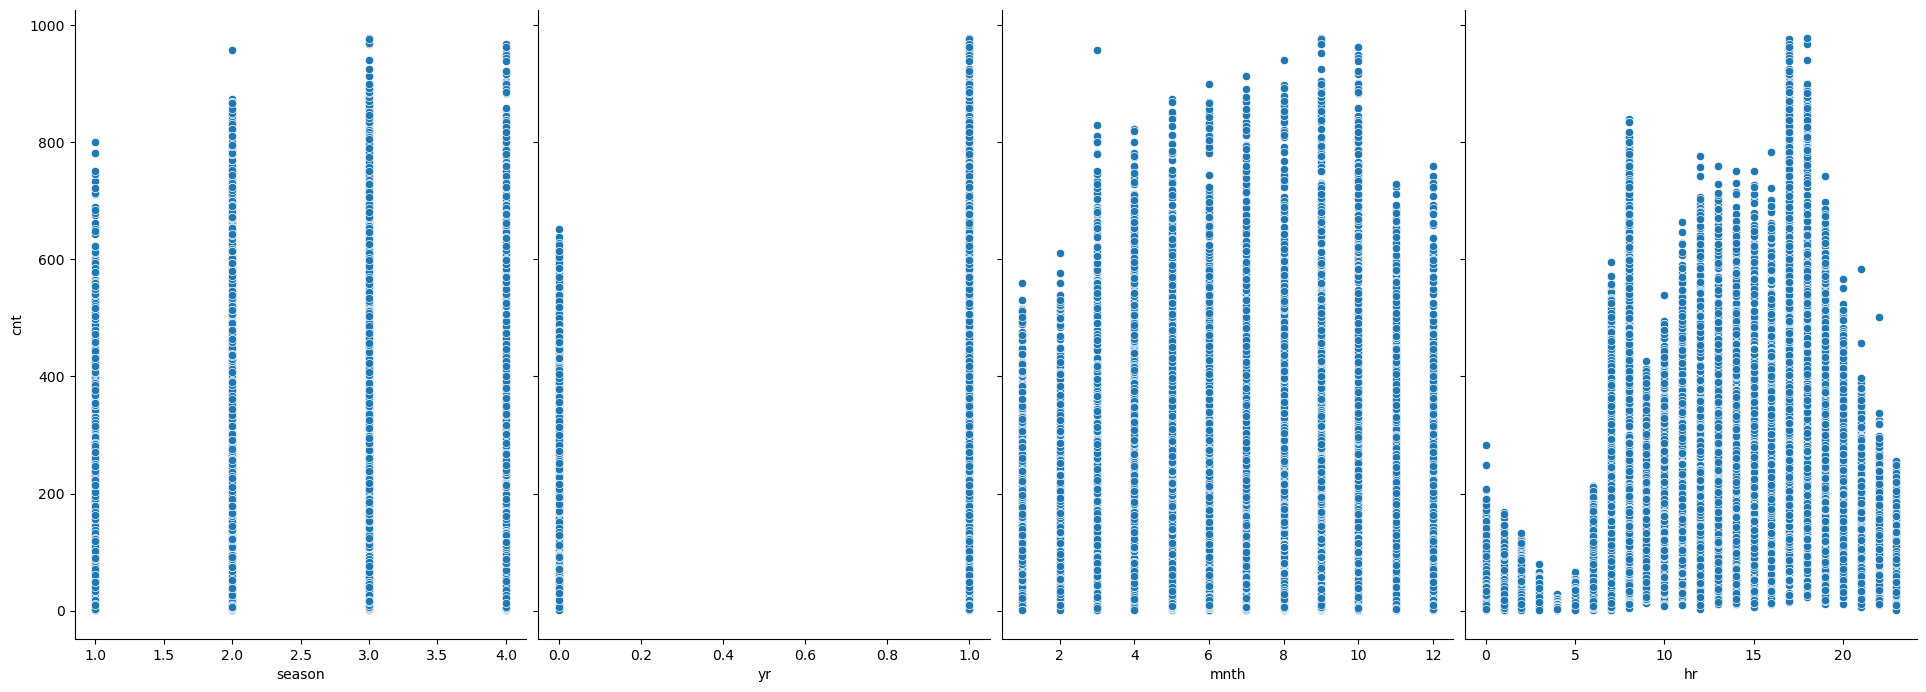

In [9]:
p1 = sns.pairplot(df, x_vars=['season','yr','mnth', "hr"], y_vars='cnt', height=7, aspect=0.7) # Visualizar datos en gráfica

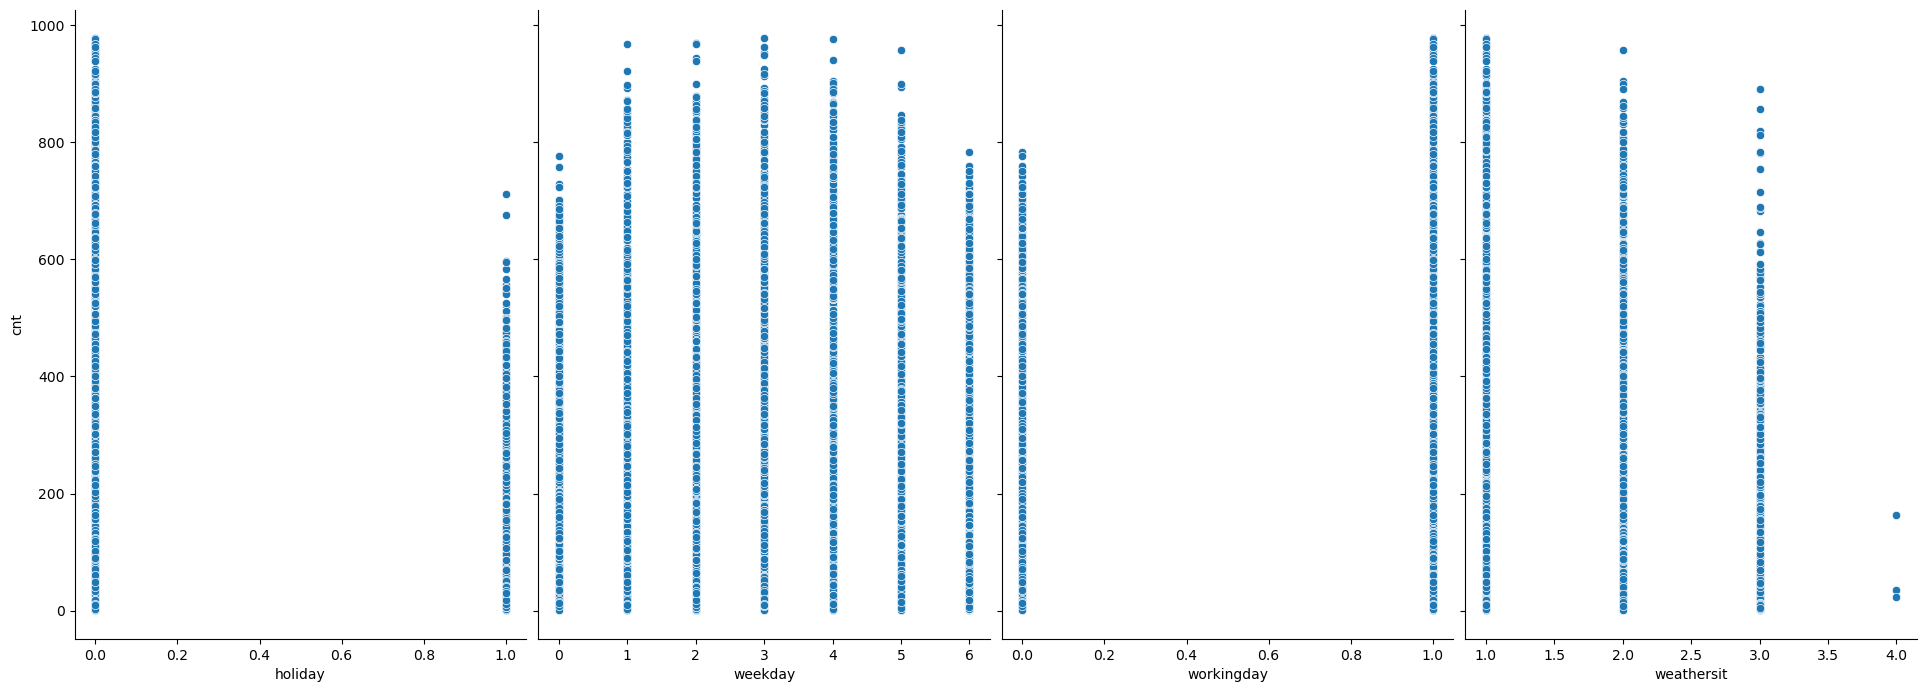

In [10]:
p2 =  sns.pairplot(df, x_vars=['holiday','weekday','workingday', "weathersit"], y_vars='cnt', height=7, aspect=0.7) # Visualizar datos en gráfica

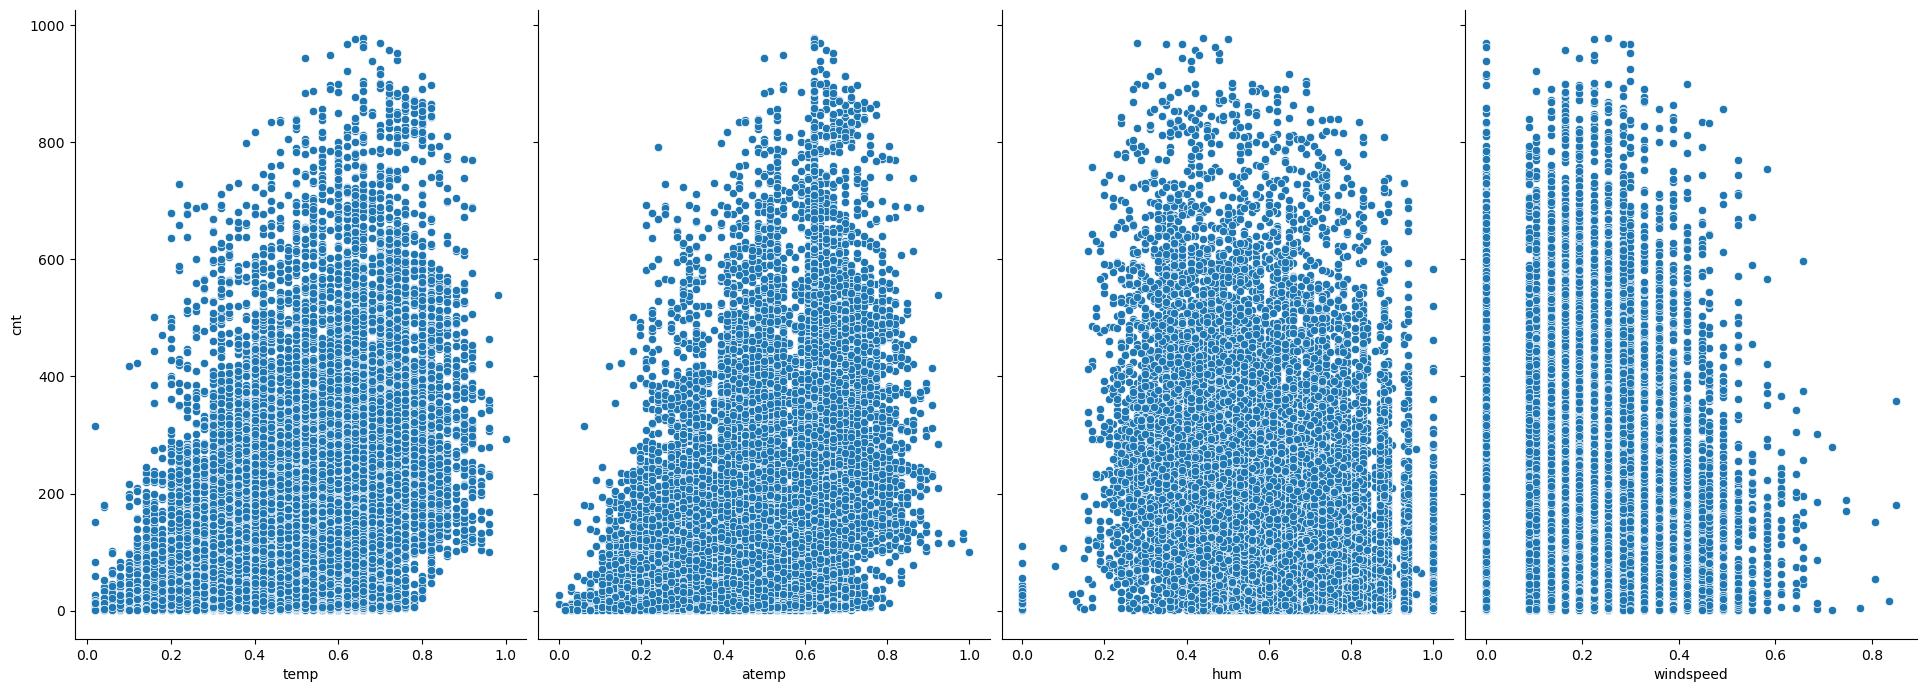

In [11]:
p3 =  sns.pairplot(df, x_vars=['temp','atemp','hum', "windspeed"], y_vars='cnt', height=7, aspect=0.7) # Visualizar datos en gráfica

**Valores nulos**

No existen valores nulos ya que nos muestra que son 17379 columnas y todos los valores estan completos por lo que no se necesita tratarlos.

**Variables a eliminar**

La variable que se puede eliminar es la de dteday ya que es como un ID y ya tenemos otras variables con información de la fecha por lo que no es necesaria.

**Variables que supongo que posteriormente se eliminarán**

1. season ya que nos da la misma información que month
2. workingday porque ya combina la de holiday y weekday 
3. atemp ya que nos da la misma información de temp

In [14]:
# Crear copia sin la variable que decidí eliminar
df_clean = df.drop(columns=["dteday"]).copy()
df_clean.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


**Separar en train y test**

In [16]:
#Dividir entre train y test

from sklearn.model_selection import train_test_split

# Separar variable objetivo de las demás
X = df_clean.drop(columns=["cnt"])   # variables
y = df_clean["cnt"]                  # target

# Dividir 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   # 20% test
    random_state=42, # semilla para reproducibilidad
)

## 2. **Preprocesamiento de los datos**
- Crea variables dummy para las variables categóricas (revisa que estén convertidas a tipo de dato "category" primero)
- Visualiza Variables numéricas, cómo se relacionan con tu variable a predecir (con los datos del train)
- Visualiza Variables categóricas (diagrama de caja de todas las variables categóricas antes de crear los dummies) contra la variable objetivo
- Qué observas de los gráficos anteriores? hay variables que pueden ser buenos/malos predictores?
- Revisa si hay alta correlación entre las variables
- Escala las variables predictoras (sólo las variables numéricas)
- Realiza una selección de características utilizando algún método (puedes sugerir algún método como correlación, RFE, etc.).

**Creación variables dummy para categóricas**

In [19]:
# Seleccionar las variables categóricas para dummies
cols_dummy = ["season","mnth", "hr", "weekday", "workingday", "holiday","weathersit"]

# Convertir las columnas a tipo category en train y test
for col in cols_dummy:
  X_train[col] = X_train[col].astype('category')
  X_test[col] = X_test[col].astype('category')

# Crear variables dummy en train y test
X_train_dummy = pd.get_dummies(X_train, columns=cols_dummy, drop_first=True)
X_test_dummy = pd.get_dummies(X_test, columns=cols_dummy, drop_first=True)
X_test_dummy = X_test_dummy.reindex(columns=X_train_dummy.columns, fill_value=0)
X_train_dummy
X_test_dummy


,yr,temp,atemp,hum,windspeed,season_2,season_3,season_4,mnth_2,mnth_3,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,holiday_1,weathersit_2,weathersit_3,weathersit_4
12830,1,0.80,0.6970,0.27,0.1940,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
8688,1,0.24,0.2273,0.41,0.2239,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
7091,0,0.32,0.3030,0.66,0.2836,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
12230,1,0.78,0.7121,0.52,0.3582,True,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
431,0,0.26,0.2273,0.56,0.3881,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6759,0,0.56,0.5303,0.94,0.1642,False,False,True,False,False,...,False,False,False,True,False,True,False,True,False,False
13989,1,0.64,0.5909,0.78,0.1940,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
173,0,0.20,0.1818,0.59,0.3582,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
16192,1,0.48,0.4697,0.77,0.1642,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


**Visualización variables numéricas antes de dummies**

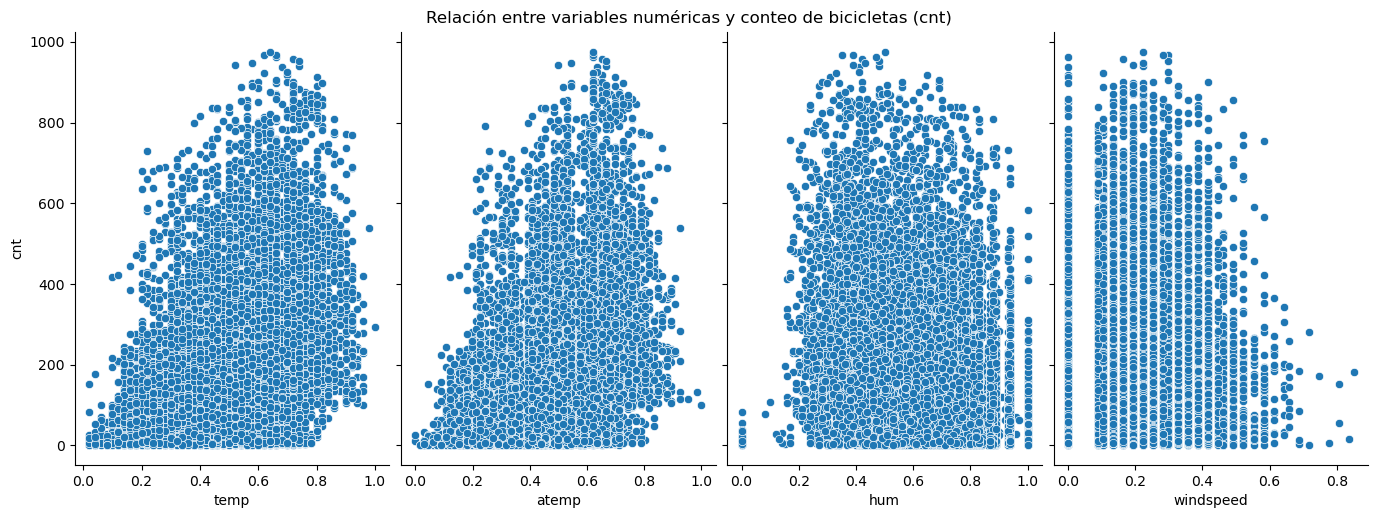

In [21]:
# Tener mis datos train juntos
train = pd.concat([X_train, y_train], axis=1)

# Seleccionar las variables numéricas 
num_cols = ["temp", "atemp", "hum", "windspeed"]

# Pairplot para visualizar su relación con la target
p = sns.pairplot(
    train,
    x_vars=num_cols,
    y_vars="cnt",
    height=5,   
    aspect=0.7  
)
p.fig.suptitle("Relación entre variables numéricas y conteo de bicicletas (cnt)", y=1.02)
plt.show()

**Visualización variables categóricas antes de dummies**

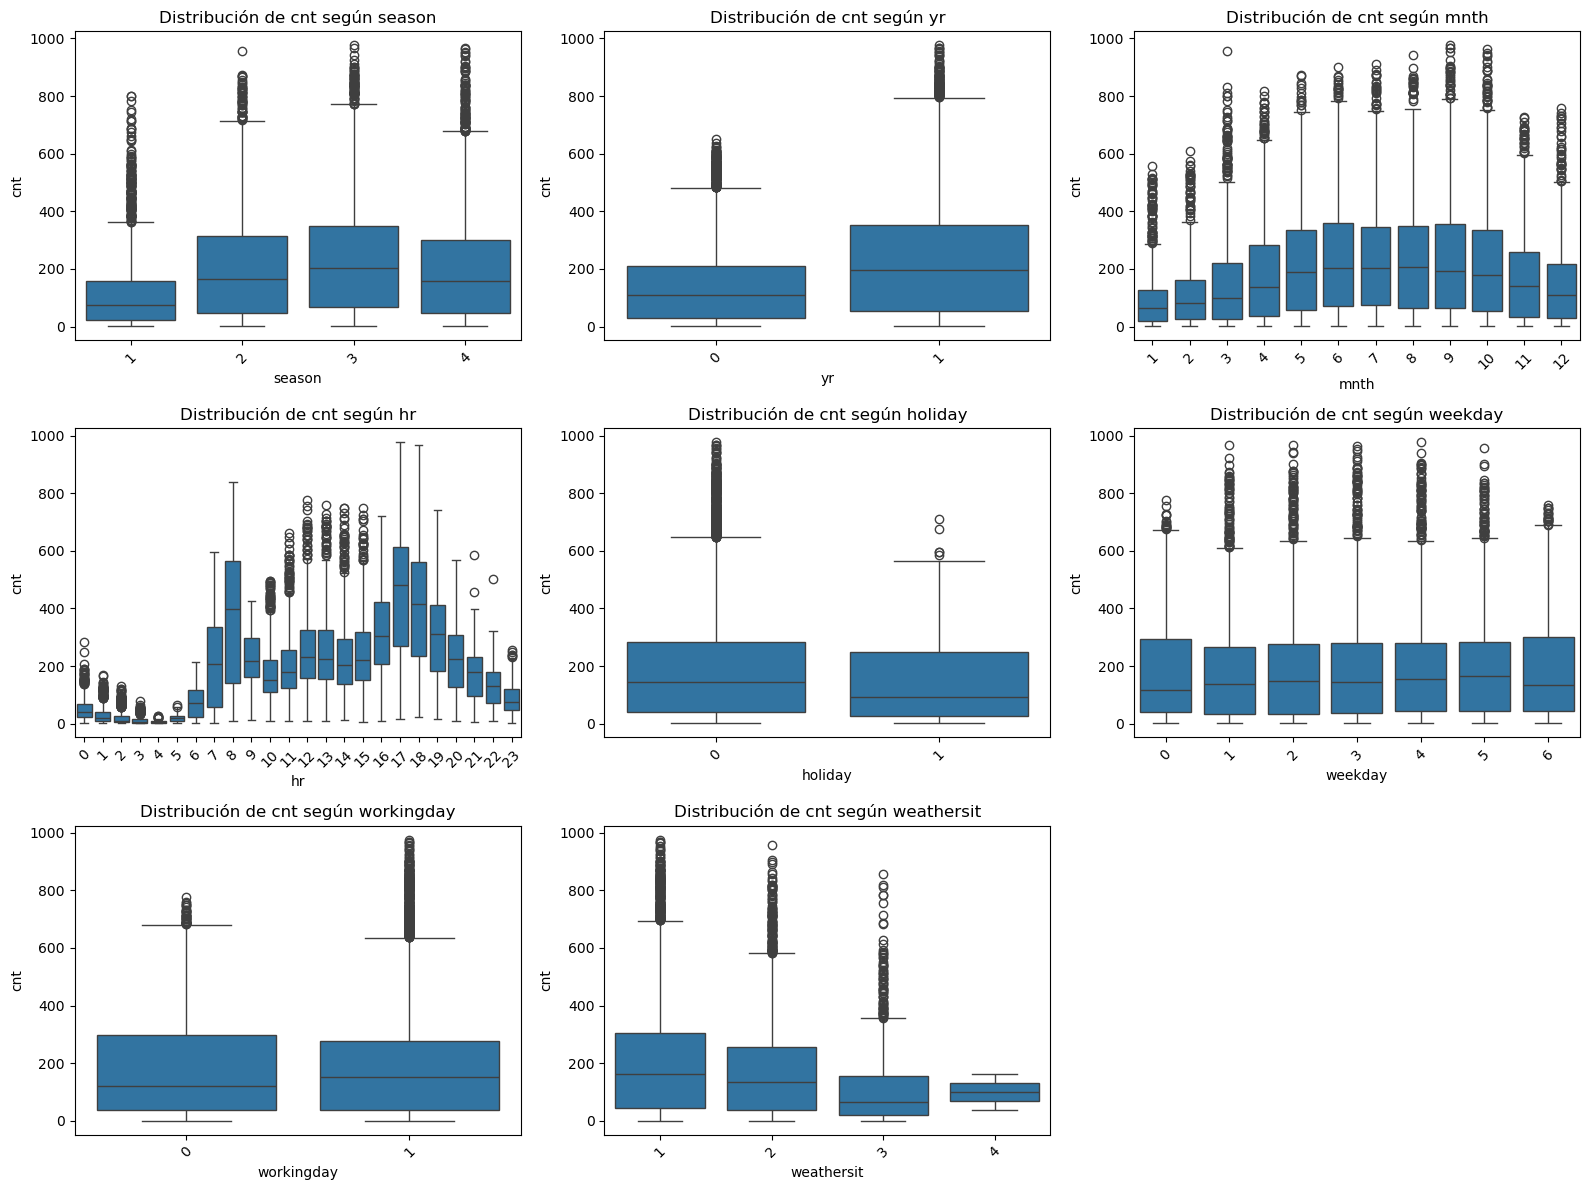

In [23]:
# Lista de variables categóricas antes de dummies
cat_cols = [ "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]

# Visualizar como se relacionan con la target
plt.figure(figsize=(16, 12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)  
    sns.boxplot(data=train, x=col, y="cnt")
    plt.title(f"Distribución de cnt según {col}")
    plt.xticks(rotation=45)  

plt.tight_layout()
plt.show()


**Observaciones de gráficos**

##### **En las variables numéricas:**
1. temp vs cnt: Se observa una relación ya que cuando la temperatura aumenta también el conteo de las bicicletas (cuando el clima es mejor la gente tiende a usar más las bicicletas). Ya que se observa una tendencia se puede considerar como un buen predictor.
2. atemp vs cnt: Se observa esa misma relación que con la de temp. Nos brinda la misma información pero debido a la tendencia clara también es un buen predictor.
3. hum vs cnt: Se observan puntos más dispersos, lo que se puede ver es que cuando se acerca a niveles más altos (entre 0.8 y 1.0) hay menos puntos y que de 0.4 - 0.8 el número de bicicletas varia. Se puede concluir que es un predictor débil ya que no se ve una tendencia muy clara.  
4. windspeed vs cnt:Se observa una relación ya que cuando la windspeed aumenta hay un menor conteo de bicicletas, esto nos dice que cuando hay viento fuerte disminuye el uso de las bicicletas. Se puede concluir que es un buen predictor ya que muestra una tendencia negativa. 

**En las variables categóricas:**
1. season vs cnt: Se nota una diferencia entre las estaciones ya que en invierno disminuye mientras que primavera y verano son temporadas de más alta demanda. Es un buen predictor ya que hay diferencias, sin embargo, nos brinda la misma información que month. 
2. yr vs cnt: Sí se nota una diferencia entre los años ya que se ve un aumento en la categoría 1, de esto se puede concluir que es un buen predictor.
3. mnth vs cnt: Se observa que los primeros meses hay un conteo más bajo mientras que en los meses 4-10 es más alto y vuelve a bajar en los últimos. Se puede concluir que es un buen predictor porque hay una variación clara a lo largo del año. 
4. hr vs cnt: Se observa un patrón muy claro ya que a horas muy tempranas de la mañana no hay conteo de bicicletas, aumenta cuando son horas pico (7-8  y 17-18), se mantiene estable entre esas horas y vuelve a bajar ya en la noche. Es un buen predictor ya que se ve el patrón muy claro de la demanda de bicicletas.
5. holiday vs cnt: Se nota una diferencia, sin embargo, no es muy grande como otras por lo que la hace un predictor medio. 
6. weekday vs cnt: Se observa que no hay una gran diferencia entre los días de la semana por lo que no sería un buen predictor ya que son muy parecidos todos los días.
7. workinday vs cnt: Solo se nota una ligera diferencia entre las categorías y debido a que son parecidas no sería un buen predictor. 
8. weathersit vs cnt: Se muestran las diferencias claras ya que dependiendo del clima se observa que el uso puede ser mayor o menor. Es un buen predictor ya que si varía dependiendo de la categoría. 

**Correlación entre las variables**

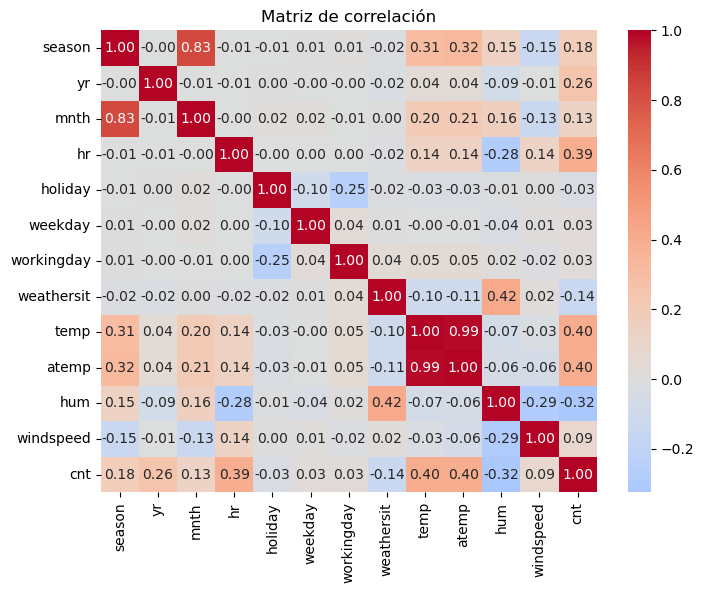

In [27]:
# Matriz de correlacion del train para ver mis relaciones entre variables
corr = train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

* Se observa que la variable temp y atemp están fuertemente relacionadas como se había sospechado
* Se observa que month y season también están fuertemente relacionadas como se había sospechado
* Observamos que temp, atemp, hr, yr, mnth, season muestran relación con la variable objetivo

**Escalamiento variables numéricas predictoras**

In [30]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Escalar 

X_train_scaled_num = pd.DataFrame(
    sc.fit_transform(X_train_dummy[num_cols]), # fit solo en train para no tener leakage
    columns=num_cols,
    index=X_train_dummy.index
)

X_test_scaled_num = pd.DataFrame(
    sc.transform(X_test_dummy[num_cols]),# solo transform en test para no tener leakage
    columns=num_cols,
    index=X_test_dummy.index
)

# Reemplazar las columnas numéricas ya escaladas en los datasets dummy
X_train_dummy[num_cols] = X_train_scaled_num
X_test_dummy[num_cols] = X_test_scaled_num

**Selección de características**

Selección por REF

In [33]:
# Seleccionar variable con el método RFE usando los datos con dummies
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

model = LinearRegression()
selector = RFE(model, n_features_to_select=40) #Seleccionar número de características
selector.fit(X_train_dummy, y_train)

# Variables seleccionadas
selected_features = X_train_dummy.columns[selector.support_]
print("Variables seleccionadas RFE:", selected_features.tolist())


Variables seleccionadas RFE: ['yr', 'temp', 'atemp', 'hum', 'season_2', 'season_3', 'season_4', 'mnth_9', 'mnth_10', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'workingday_1', 'holiday_1', 'weathersit_3', 'weathersit_4']


## 3. **Detección de multicolinealidad**
- Calcula el VIF (Variance Inflation Factor) para detectar multicolinealidad entre las variables independientes (esto no lo vimos, pero te pido buscar la interpretación del VIF en internet)

**Interpretación de VIF**

VIF = 1 → No hay correlación lineal con ninguna otra variable (ideal).

1 < VIF < 5 → Colinealidad moderada, generalmente aceptable.

VIF ≥ 5 → Señal de colinealidad alta, empieza a ser un problema (considera revisar/eliminar).

VIF ≥ 10 → Colinealidad muy fuerte, casi seguro deberías eliminar esa variable o transformarla.

- Si detectas multicolinealidad, realiza la eliminación de variables y justifica por qué las variables eliminadas son redundantes.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Obtener el VIF de las seleccionadas con RFE
X_train_seleccionadas = X_train_dummy[selected_features].astype(float) # Cambiar a float

vif = pd.DataFrame()
vif['Features'] = X_train_seleccionadas.columns
vif['VIF'] = [variance_inflation_factor(X_train_seleccionadas.values, i)
              for i in range(X_train_seleccionadas.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)
print(vif)

C:\Users\maria\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


        Features    VIF
37     holiday_1    inf
32     weekday_2    inf
33     weekday_3    inf
34     weekday_4    inf
31     weekday_1    inf
35     weekday_5    inf
36  workingday_1    inf
1           temp  44.31
2          atemp  41.70
5       season_3   4.30
6       season_4   2.48
4       season_2   2.47
0             yr   1.91
8        mnth_10   1.62
3            hum   1.58
12          hr_5   1.29
13          hr_6   1.28
38  weathersit_3   1.28
7         mnth_9   1.28
15          hr_8   1.27
14          hr_7   1.27
11          hr_4   1.27
9           hr_2   1.27
23         hr_16   1.26
20         hr_13   1.25
24         hr_17   1.25
22         hr_15   1.25
21         hr_14   1.25
16          hr_9   1.25
25         hr_18   1.24
29         hr_22   1.24
30         hr_23   1.24
19         hr_12   1.24
10          hr_3   1.24
26         hr_19   1.23
27         hr_20   1.23
28         hr_21   1.23
18         hr_11   1.23
17         hr_10   1.23
39  weathersit_4   1.00


In [39]:
# Eliminar las columnas que tienen un alto valor del vif
cols_drop_vif = [
    "holiday_1",
    "workingday_1",
    "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "atemp"
]
X_train_rfe = X_train_seleccionadas.drop(columns=cols_drop_vif, errors="ignore")
X_test_rfe  = X_test_dummy[X_train_rfe.columns] # Que el test y el train tengan las mismas columnas

Los valores del VIF de algunas variables son inf por lo que se eliminaron ya que esto significa que tienen una multicolinealidad alta, de igual manera se elimino atemp ya que tiene una alta colinealidad con temp, las demás tienen valores que rondan por el 1 por lo que se conservan 

## 4. **Entrenamiento y validación del modelo**

- Entrena el modelo utilizando regresión lineal y evalúa su rendimiento en el conjunto de entrenamiento y prueba.
- Implementa cross-validation y reporta las métricas promedio (RMSE, MAE, R²).
- Visualiza la curva de aprendizaje
- El modelo está haciendo overfittint/underfitting?

**Entrenamiento modelo**

In [43]:
#Entrenamos el modelo

#Inicializamos el modelo
reg_rfe = LinearRegression()

#Entrenamos el modelo con los datos de entrenamiento
reg_rfe.fit(X_train_rfe, y_train)

#Predecimos con el modelo entrenado en el test
y_pred_rfe_test = reg_rfe.predict(X_test_rfe)


#Predecimos con el modelo entrenado en el train
y_pred_train_rfe = reg_rfe.predict(X_train_rfe)


**Cross validation y métricas**

In [45]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Métricas para RFE
print("--- RFE ---")
print("R² train:", r2_score(y_train, y_pred_train_rfe))
print("R² test: ", r2_score(y_test, y_pred_rfe_test))
print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_pred_train_rfe)))
print("RMSE test: ", np.sqrt(mean_squared_error(y_test, y_pred_rfe_test)))
print("MAE train:", mean_absolute_error(y_train, y_pred_train_rfe))
print("MAE test: ", mean_absolute_error(y_test, y_pred_rfe_test))


--- RFE ---
R² train: 0.6828065481175184
R² test:  0.6769235614428724
RMSE train: 102.62277111764278
RMSE test:  101.14518436400685
MAE train: 75.88350412754822
MAE test:  74.3003664665293


In [46]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

# KFold para regresion
kf = KFold(n_splits=10, shuffle=True, random_state=42)


# Pipeline para RFE
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),  
    ('model', LinearRegression())
])

scores_rfe = cross_val_score(pipeline_rfe, X_train_rfe, y_train, cv=kf, scoring='neg_root_mean_squared_error')
print("--- RFE ---")
print(f"RMSE scores: {-scores_rfe}")
print(f"Mean RMSE: {-scores_rfe.mean():.4f}\n")


--- RFE ---
RMSE scores: [ 98.52555034 100.2395336  101.83703526 102.93200033 107.20565754
 102.01195662 103.94444228 107.26755044 100.74834167 103.89253211]
Mean RMSE: 102.8605



**Curva aprendizaje**

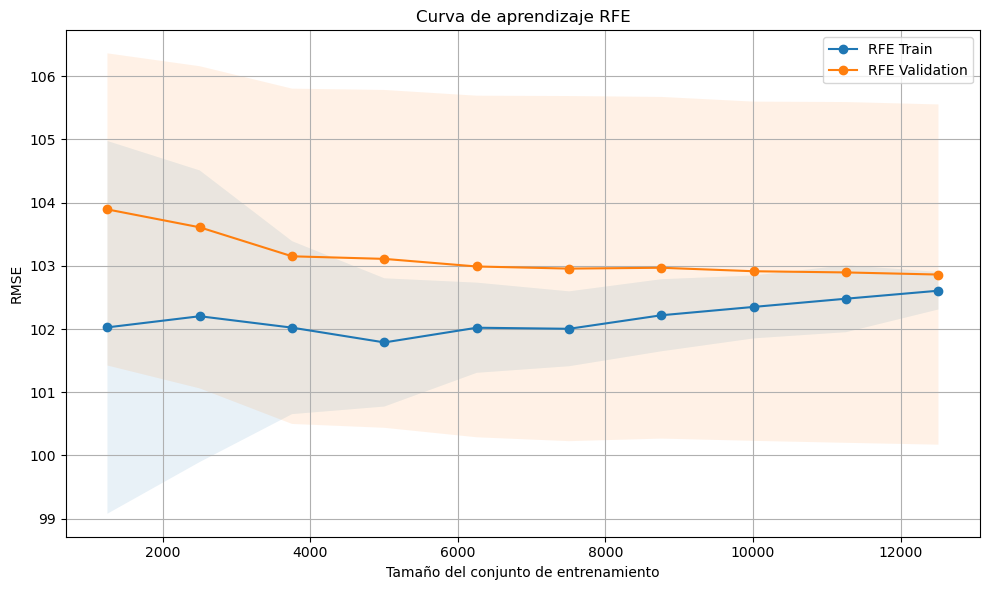

In [48]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Lasso

# Curva de aprendizaje RFE
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

train_sizes_rfe, train_scores_rfe, val_scores_rfe = learning_curve(
    estimator=pipeline_rfe,
    X=X_train_rfe,
    y=y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean_rfe = -train_scores_rfe.mean(axis=1)
train_std_rfe = train_scores_rfe.std(axis=1)
val_mean_rfe = -val_scores_rfe.mean(axis=1)
val_std_rfe = val_scores_rfe.std(axis=1)


# Curva de aprendizaje RFE
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_rfe, train_mean_rfe, 'o-', label='RFE Train')
plt.plot(train_sizes_rfe, val_mean_rfe, 'o-', label='RFE Validation')
plt.fill_between(train_sizes_rfe, train_mean_rfe - train_std_rfe, train_mean_rfe + train_std_rfe, alpha=0.1)
plt.fill_between(train_sizes_rfe, val_mean_rfe - val_std_rfe, val_mean_rfe + val_std_rfe, alpha=0.1)
plt.title('Curva de aprendizaje RFE')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Overfitting o Underfitting**



No hay overfitting ya que las líneas de Train y Validation están muy cercanas y convergen. En el RMSE los valores no difieren mucho si hubiera overfitting habría un error más bajo en Train y un error mucho más alto en Test y en la parte de R^2 también son similares los valores lo que significa que generaliza bien. Sí hay un ligero underfitting ya que el modelo se queda corto para explicar toda la variabilidad.
 

## 5. **Interpretación de los coeficientes**

*NOTA: Esto no lo vimos en clase, por lo tanto te tocará investigar cómo interpretar los coeficientes. Interpretar los coeficientes es de suma importancia para poder explicar tu modelo*

- Interpreta los coeficientes del modelo final (model.coef_) y discute cuáles son las variables más importantes para predecir la variable objetivo.
- ¿Cómo afectan los signos y magnitudes de los coeficientes a la interpretación del modelo?

In [52]:
# Coeficientes del modelo RFE
coef_rfe = pd.DataFrame({
    "Variable": X_train_rfe.columns,
    "Coeficiente": reg_rfe.coef_,
    "Importancia_abs": abs(reg_rfe.coef_)
}).sort_values(by="Importancia_abs", ascending=False)

print("Coeficientes - Modelo RFE")
print(coef_rfe)


Coeficientes - Modelo RFE
        Variable  Coeficiente  Importancia_abs
23         hr_17   386.828947       386.828947
24         hr_18   347.484263       347.484263
14          hr_8   323.698814       323.698814
25         hr_19   241.620919       241.620919
22         hr_16   229.611159       229.611159
18         hr_12   180.884775       180.884775
13          hr_7   179.914997       179.914997
19         hr_13   176.059134       176.059134
15          hr_9   170.361813       170.361813
26         hr_20   166.846061       166.846061
21         hr_15   163.707605       163.707605
20         hr_14   154.419221       154.419221
17         hr_11   138.544734       138.544734
31  weathersit_4  -123.269624       123.269624
27         hr_21   117.263826       117.263826
16         hr_10   116.187839       116.187839
0             yr    85.499859        85.499859
28         hr_22    79.760278        79.760278
30  weathersit_3   -61.422911        61.422911
5       season_4    57.542365     

De los coeficientes se puede interpretar que las horas del día, especialmente las horas pico donde mucha gente se transporta al trabajo, escuela o casa, son las variables más importantes para predecir mi variable objetivo y son positivas lo que nos dice que en esas horas el conteo de bicicletas aumenta mientras que las variables de la condición del clima son negativas lo que hace sentido ya que ante un mal clima hay una disminución de la demanda de bicicletas. También se observa como las horas muy tempranas de la mañana tienen un valor negativo ya que tampoco hay mucha demanda. 


## 6. **Mejora del modelo**

- Si el modelo presenta un mal ajuste, propón al menos formas de mejorarlo.
- Evalúa si las mejoras introducidas realmente generan un mejor desempeño del modelo.

El modelo no presenta un mal ajuste porque las métricas de desempeño muestran que generaliza correctamente: el R² de entrenamiento y de prueba son muy cercanos, lo que indica que el modelo explica de manera consistente la variabilidad de los datos sin sobreajustarse al conjunto de entrenamiento. Sin embargo, si hay un ligero underfitting por lo que existe un área de mejora. 

Para mejorarlo le agregue un Lasso a la selección de características y con esto el modelo  explica un poco más de la variabilidad tanto en train como en testy el error en RMSE y MAE bajan ligeramente lo que quiere decir que las predicciones son un poquito más precisas. Esto sucede ya que Lasso mejora el modelo penalizando variables poco útiles o colineales, mejorando estabilidad.

In [116]:
#Modelo con RFE más Lasso

from sklearn.linear_model import Lasso, LinearRegression

lasso_model = Lasso(alpha=0.01, max_iter=10000) #Agregar Lasso
selector_lasso = RFE(lasso_model, n_features_to_select=40) # Sumar Lasso al RFE
selector_lasso.fit(X_train_dummy, y_train)

selected_features_lasso = X_train_dummy.columns[selector_lasso.support_]
print("Variables seleccionadas con RFE + Lasso:", selected_features_lasso.tolist()) # Seleccionar las variables

X_train_lasso = X_train_dummy[selected_features_lasso].astype(float)

col_drop_vif = "atemp" # Al imprimir vi que quedaba atemp por lo que la removí por su alta correlación con temp
X_train_lasso = X_train_lasso.drop(columns=col_drop_vif, errors="ignore") # Quito atemp


X_test_lasso = X_test_dummy[X_train_lasso.columns] # Conjunto de prueba con las mismas columnas

# Entrenar modelo final con regresión lineal
reg_lasso = LinearRegression()
reg_lasso.fit(X_train_lasso, y_train)

#  Predicciones y métricas
y_pred_train_lasso = reg_lasso.predict(X_train_lasso)
y_pred_test_lasso  = reg_lasso.predict(X_test_lasso)

print("\nModelo final: RFE + Lasso + Regresión Lineal")
print("R² train:", r2_score(y_train, y_pred_train_lasso))
print("R² test: ", r2_score(y_test, y_pred_test_lasso))
print("RMSE train:", mean_squared_error(y_train, y_pred_train_lasso, squared=False))
print("RMSE test: ", mean_squared_error(y_test, y_pred_test_lasso, squared=False))
print("MAE train:", mean_absolute_error(y_train, y_pred_train_lasso))
print("MAE test: ", mean_absolute_error(y_test, y_pred_test_lasso))


Variables seleccionadas con RFE + Lasso: ['yr', 'temp', 'atemp', 'hum', 'season_2', 'season_3', 'season_4', 'mnth_5', 'mnth_7', 'mnth_9', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_6', 'workingday_1', 'holiday_1', 'weathersit_3', 'weathersit_4']

Modelo final: RFE + Lasso + Regresión Lineal
R² train: 0.6851764763162926
R² test:  0.6800085828003735
RMSE train: 102.23867650704337
RMSE test:  100.66111389092568
MAE train: 75.78227089298768
MAE test:  74.27745294576404


C:\Users\maria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\maria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 7. **Verificación de las suposiciones del modelo**

- Revisa los residuales se distribuyen normalmente con media cero.
- Existió relación lineal entre las X y Y?
- Con tu modelo final, existe multicolinealidad en tus variables independientes?


**Residuales media de cero**

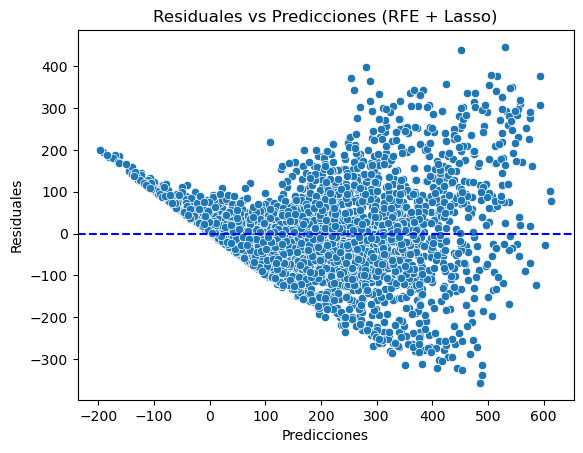

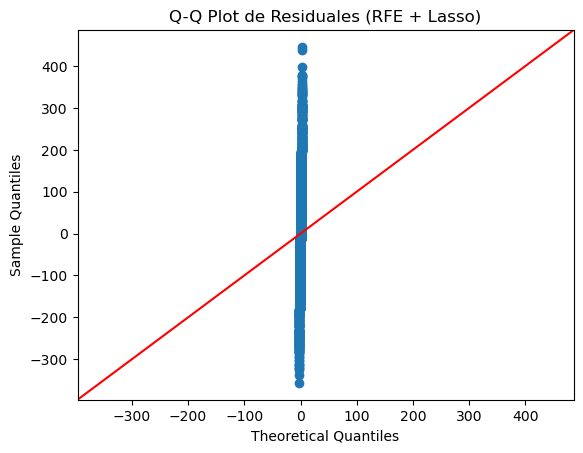

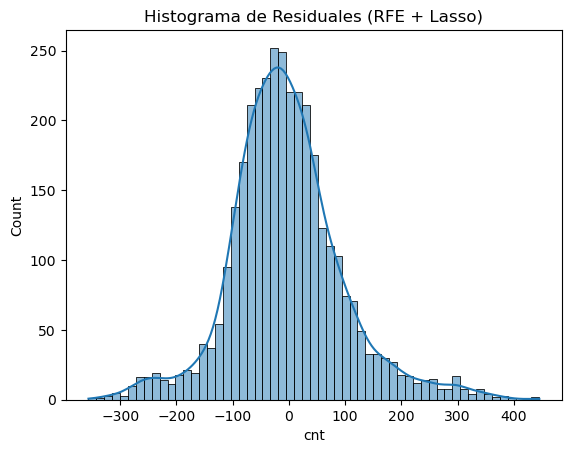

Shapiro-Wilk Test p-value (RFE + Lasso): 0.0000


In [110]:
import statsmodels.api as sm
import scipy.stats as stats

# 1. Cálculo de residuales
residuales_lasso = y_test - y_pred_test_lasso

# 2. Scatterplot de residuales vs predicciones
sns.scatterplot(x=y_pred_test_lasso, y=residuales_lasso)
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuales")
plt.title("Residuales vs Predicciones (RFE + Lasso)")
plt.show()

# 3. Q-Q Plot para normalidad
sm.qqplot(residuales_lasso, line='45')
plt.title("Q-Q Plot de Residuales (RFE + Lasso)")
plt.show()

# 4. Histograma + KDE
sns.histplot(residuales_lasso, kde=True)
plt.title("Histograma de Residuales (RFE + Lasso)")
plt.show()

# 5. Prueba de normalidad (Shapiro-Wilk)
shapiro_test_lasso = stats.shapiro(residuales_lasso)
print(f'Shapiro-Wilk Test p-value (RFE + Lasso): {shapiro_test_lasso.pvalue:.4f}')

En el primer gráfico se observa que la nube de puntos sí se centra en torno a esa línea, lo que indica que en promedio los errores no se desvían hacia arriba ni hacia abajo eso significa que el modelo no tiene un sesgo fuerte en sus predicciones. Sin embargo, cuando las predicciones son bajas, los residuales están más concentrados, y conforme aumentan las predicciones, la dispersión de los residuales se hace mayor.

Del Q-Q plot se puede observar que los residuales no siguen normalidad ya que estan muy concentrados en una línea vertical.

En el histograma, se observa que los residuales parecen concentrarse alrededor de cero y tener una forma parecida a la normal y con el test se debe rechazar la hipótesis nula de normalidad por lo que estadísticamente no siguen una distribución normal perfecta..

**Relación lineal**

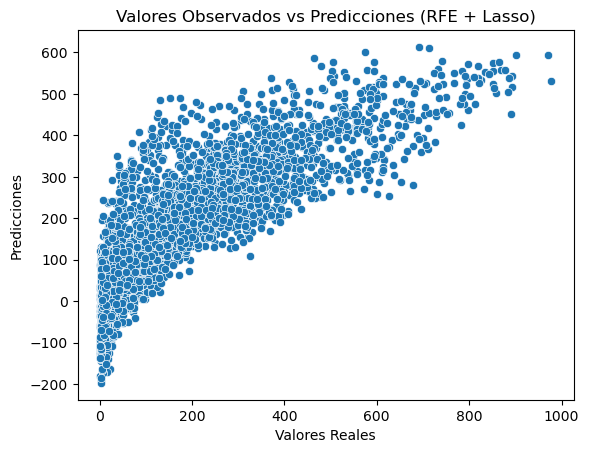

In [112]:
# 6. Observados vs Predichos
sns.scatterplot(x=y_test, y=y_pred_test_lasso)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Observados vs Predicciones (RFE + Lasso)")
plt.show()

De esta gráfica, se puede observar que sí existe una relación lineal entre X y Y ya que los puntos siguen una tendencia creciente, es decir, a medida que aumentan los valores reales también lo hacen las predicciones.

**Multicolinealidad**

In [114]:
X_vif_lasso = X_train_lasso.astype(float).copy()

vif_final_lasso = pd.DataFrame()
vif_final_lasso["Features"] = X_vif_lasso.columns
vif_final_lasso["VIF"] = [
    variance_inflation_factor(X_vif_lasso.values, i)
    for i in range(X_vif_lasso.shape[1])
]
vif_final_lasso["VIF"] = round(vif_final_lasso["VIF"], 2)

print("\n=== VIF final (RFE + Lasso) ===")
print(vif_final_lasso.sort_values(by="VIF", ascending=False))


=== VIF final (RFE + Lasso) ===
        Features   VIF
4       season_3  5.71
35  workingday_1  4.83
5       season_4  3.31
3       season_2  3.16
1           temp  3.12
0             yr  1.96
9        mnth_11  1.84
34     weekday_6  1.83
7         mnth_7  1.71
2            hum  1.60
6         mnth_5  1.58
10       mnth_12  1.47
8         mnth_9  1.45
15          hr_5  1.45
16          hr_6  1.44
14          hr_4  1.43
12          hr_2  1.42
17          hr_7  1.42
18          hr_8  1.42
11          hr_1  1.41
26         hr_16  1.39
33         hr_23  1.39
27         hr_17  1.39
19          hr_9  1.39
23         hr_13  1.39
13          hr_3  1.39
25         hr_15  1.38
32         hr_22  1.38
24         hr_14  1.37
22         hr_12  1.37
28         hr_18  1.37
29         hr_19  1.37
30         hr_20  1.37
31         hr_21  1.37
20         hr_10  1.37
21         hr_11  1.36
37  weathersit_3  1.27
36     holiday_1  1.17
38  weathersit_4  1.00


Los valores del VIF de el modelo final no presentan multicolinealidad ya que la mayoría están por valores abajo del 5 y muchos de ellos rondan en el 1. Las que se muestran más altas son las seasons y la temp debido a que las estaciones del año influyen directamente en la temperatura , lo que genera cierta correlación natural entre ambas. Sin embargo, sus valores siguen siendo aceptables y no representan un problema para la estabilidad del modelo.